# YOLOv12 Nano

In [ ]:
# Check python version
!python --version

Python 3.11.13


In [ ]:
try:
  import google.colab
  IN_COLAB = True

  # Install Packages
  !pip install git+https://github.com/sunsmarterjie/yolov12.git
  !pip install huggingface_hub

  # For TFLite Packages
  !pip install onnx
  !pip install onnxscript

  from google.colab import files
except ImportError:
   IN_COLAB = False

from ultralytics import YOLO
import os
import onnx

  Cloning https://github.com/sunsmarterjie/yolov12.git to /tmp/pip-req-build-67l00uwk
  Running command git clone --filter=blob:none --quiet https://github.com/sunsmarterjie/yolov12.git /tmp/pip-req-build-67l00uwk
  Resolved https://github.com/sunsmarterjie/yolov12.git to commit d3cbe103b992ff6dd20c722e84e1b6f18f4c5efc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.1 MB/

In [ ]:
def detect_images(model):
    # Inference on images
    img_path = r""
    images = [os.path.join(img_path, img) for img in os.listdir(img_path) if img.endswith(('.png', '.jpg'))]
    results = model(images)

    dir = os.path.dirname(img_path)
    output_dir = os.path.join(dir,'yolo_output')
    os.makedirs(output_dir, exist_ok=True)

    for i, result in enumerate(results):
        boxes = result.boxes  # Boxes object for bounding box outputs
        obb = result.obb  # Oriented boxes object for OBB outputs
        result.show()  # display to screen
        result.save(filename=os.path.join(output_dir, f"{os.path.basename(images[i])}"))
        print(f"{os.path.basename(images[i])} saved in {output_dir}.")

def detect_video(model):
    # Inference on video
    vid_path = r""
    result = model(vid_path, show=True, save=True)

def detect_cam(model):
    # Inference on camera in real-time
    model.predict(source="0", show=True)

def test_coco(model):
    """Test on COCO dataset"""
    # Test 1: Interrupted by insufficient storage space
    # Test 2: Conf and max_det are not set to default
    # model.val(data="coco.yaml", save_json=True, conf=0.6, max_det=10)

    # Test 3
    model.val(data="coco.yaml", save_json=True)

def export(model):
    # Exporting the model
    # model.export(format="onnx")
    model.export(
        format="tflite",
        imgsz=128,
        simplify=True,
        int8=True,
        data="coco.yaml",
        fraction=0.1
    )

    if IN_COLAB:
        download()

def download():
    # Download ONNX files
    onnx_model = "yolov12n.onnx"
    onnx_data = "yolov12n.onnx.data"

    if os.path.exists(onnx_model) and os.path.exists(onnx_data):
        files.download(onnx_model)
        print(f"ONNX model downloaded ✅")
        files.download(onnx_data)
        print(f"ONNX model data downloaded ✅")
    else:
        print("ONNX files were unsuccessfully downloaded.")

    # Download TensorFlow files
    tf_model = "yolov12n_saved_model"

    if os.path.exists(tf_model):
        !zip -r '/content/yolov12n_saved_model.zip' '/content/yolov12n_saved_model'
        files.download("/content/yolov12n_saved_model.zip")
        print(f"TensorFlow model downloaded ✅")
    else:
        print("TensorFlow model was unsuccessfully downloaded.")

def main():
    # Load pretrained YOLO version 12 nano
    model = YOLO('yolov12n.pt')
    export(model)

if __name__ == '__main__':
    main()

Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv12n summary (fused): 376 layers, 2,542,440 parameters, 0 gradients, 6.0 GFLOPs

PyTorch: starting from 'yolov12n.pt' with input shape (1, 3, 128, 128) BCHW and output shape(s) (1, 84, 336) (5.3 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'onnx2tf>1.17.5,<=1.26.3', 'onnxslim>=0.1.31', 'tflite_support', 'onnxruntime'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.6/146.6 kB 6.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 200.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.6/445.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.9/235.9 kB 

100%|██████████| 1.11M/1.11M [00:00<00:00, 18.6MB/s]
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|██████████| 1/1 [00:00<00:00, 43.20file/s]



ONNX: starting export with onnx 1.20.1 opset 19...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 4.6s, saved as 'yolov12n.onnx' (9.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco.yaml'

Dataset 'coco.yaml' images not found ⚠️, missing path '/content/datasets/..datasets/coco/val2017.txt'


100%|██████████| 169M/169M [00:00<00:00, 274MB/s]
Unzipping /content/datasets/..datasets/coco2017labels-segments.zip to /content/datasets/..datasets/coco...: 100%|██████████| 122232/122232 [00:25<00:00, 4750.32file/s]

Dataset download success ✅ (390.1s), saved to /content/datasets



100%|██████████| 755k/755k [00:00<00:00, 14.6MB/s]
Scanning /content/datasets/..datasets/coco/labels/val2017... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:15<00:00, 312.55it/s]


New cache created: /content/datasets/..datasets/coco/labels/val2017.cache
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.26.3...
Saved artifact at 'yolov12n_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 128, 128, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 336), dtype=tf.float32, name=None)
Captures:
  138578007877648: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138578007876112: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  138578007878224: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  138578007881104: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138578007882640: TensorSpec(shape=(3, 3, 8, 16), dtype=tf.float32, name=None)
  138578007881872: TensorSpec(shape=(3, 3, 8, 16), dtype=tf.float32, name=None)
  138578007882448: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  138578017612624: TensorSpec(shape=(

100%|██████████| 5.26M/5.26M [00:00<00:00, 74.1MB/s]


Dataset unzipped.

0: 640x640 1 dog, 410.4ms
1: 640x640 1 car, 2 buss, 1 truck, 410.4ms
2: 640x640 3 trucks, 410.4ms
Speed: 22.4ms preprocess, 410.4ms inference, 16.9ms postprocess per image at shape (1, 3, 640, 640)


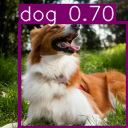

3.png saved in yolo_output.


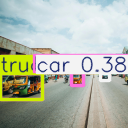

1.png saved in yolo_output.


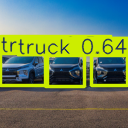

2.png saved in yolo_output.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Output files downloaded ✅


In [ ]:
def detect_images(model, img_path):
    images = [os.path.join(img_path, img) for img in os.listdir(img_path) if img.endswith(('.png', '.jpg'))]
    results = model(images)

    dir = os.path.dirname(img_path)
    output_dir = os.path.join(dir,'yolo_output')
    os.makedirs(output_dir, exist_ok=True)

    for i, result in enumerate(results):
        boxes = result.boxes  # Boxes object for bounding box outputs
        obb = result.obb  # Oriented boxes object for OBB outputs
        result.show()  # display to screen
        result.save(filename=os.path.join(output_dir, f"{os.path.basename(images[i])}"))
        print(f"{os.path.basename(images[i])} saved in {output_dir}.")

    if IN_COLAB:
      output_download(output_dir)

def detect_video(model, vid_path):
    result = model(vid_path, show=True, save=True)

def detect_cam(model):
    # Inference on camera in real-time
    model.predict(source="0", show=True)

def test_coco(model):
    """Test on COCO dataset"""
    # Test 1: Interrupted by insufficient storage space
    # Test 2: Conf and max_det are not set to default
    # model.val(data="coco.yaml", save_json=True, conf=0.6, max_det=10)

    # Test 3
    model.val(data="coco.yaml", save_json=True)

def export(model):
    # Exporting the model
    # model.export(format="onnx")
    model.export(
        format="tflite",
        imgsz=128,
        simplify=True,
        int8=True,
        data="coco.yaml",
        fraction=0.1
    )

    if IN_COLAB:
        model_download()

def model_download():
    # Download ONNX files
    onnx_model = "yolov12n.onnx"
    onnx_data = "yolov12n.onnx.data"

    if os.path.exists(onnx_model) and os.path.exists(onnx_data):
        files.download(onnx_model)
        print(f"ONNX model downloaded ✅")
        files.download(onnx_data)
        print(f"ONNX model data downloaded ✅")
    else:
        print("ONNX files were unsuccessfully downloaded.")

    # Download TensorFlow files
    tf_model = "yolov12n_saved_model"

    if os.path.exists(tf_model):
        !zip -r /content/{tf_model.zip} /content/
        files.download(os.path.join("/content", tf_model + ".zip"))
        print(f"TensorFlow model downloaded ✅")
    else:
        print("TensorFlow model was unsuccessfully downloaded.")

def extract_zip(dataset):
    if IN_COLAB:
      !unzip -q /content/{dataset}.zip -d /content/

      dataset = os.path.join("/content", dataset)
      if os.path.exists(dataset):
        print("Dataset unzipped.")
      else:
        print("Dataset was not extracted.")

def output_download(output_dir):
    # Download output of predict()
    if os.path.exists(output_dir):
        output_zip = output_dir + ".zip"
        !zip -rq {output_zip} /content/{output_dir}
        files.download(output_zip)
        print("Output files downloaded ✅")
    else:
        print("Output files were not downloaded.")

def main():
    # Load pretrained YOLO version 12 nano
    model = YOLO('yolov12n.pt')

    # Inference on images directory or video path or zipped dataset
    input_path = r"yolo_images"
    extract_zip(input_path)

    detect_images(model, input_path)

if __name__ == '__main__':
    main()